# Exploração da camada Bronze

Análise exploratória dos dados exatamente como chegaram da fonte (Base dos Dados / INEP), antes de definir as transformações da camada Silver. O que quero responder aqui:

1. O que existe em cada uma das 6 entidades e como elas se relacionam?
2. Qual a "cara" dos microdados de alunos — tipos, nulos, distribuição da proficiência?
3. A coluna `alfabetizado`, que já vem pronta na base, bate com a regra dos 743 pontos?
4. As chaves de relacionamento fecham entre as tabelas?

> Antes de rodar este notebook, é preciso materializar a Bronze: `python src/01_bronze/ingestao_batch_bigquery.py` (a partir da raiz do projeto).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

BRONZE = Path("../data/bronze/batch")
AZUL = "#4269d0"
GRAFITE = "#374151"

pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})

## Visão geral das entidades

In [2]:
entidades = {p.name: pd.read_parquet(p) for p in sorted(BRONZE.iterdir())}

pd.DataFrame({
    "linhas": {k: len(df) for k, df in entidades.items()},
    "colunas": {k: df.shape[1] for k, df in entidades.items()},
    "memoria_mb": {k: round(df.memory_usage(deep=True).sum() / 1e6, 1) for k, df in entidades.items()},
}).sort_values("linhas", ascending=False)

,linhas,colunas,memoria_mb
alunos,3867999,15,872.4
municipio,23995,18,5.8
meta_alfabetizacao_municipio,10704,16,2.7
uf,145,18,0.0
meta_alfabetizacao_uf,81,15,0.0
meta_alfabetizacao_brasil,3,14,0.0


## Metas: o alvo que o país precisa atingir

Começo pelas tabelas pequenas, que dão o contexto do problema. A de metas do Brasil cabe inteira na tela (tiro só as colunas de controle da ingestão):

In [3]:
entidades["meta_alfabetizacao_brasil"].drop(columns=["_row_hash", "_ingestion_ts", "_source"])

,ano,rede,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,percentual_participacao
0,2025,Pública,66.0,60.0,64.00,67.00,71.00,74.00,77.00,80.0,88.00
1,2024,Pública,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37
2,2023,Pública,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.00


Cada linha é um ano de aferição da rede pública: `taxa_alfabetizacao` é o resultado observado e as colunas `meta_alfabetizacao_2024`...`2030` desenham a trajetória até os 80% em 2030.

Duas anotações importantes daqui:

- a taxa nacional publicada foi **55,9% em 2023** e **59,2% em 2024** — mais abaixo tento reproduzir esses números a partir dos microdados;
- as metas por UF e por município seguem exatamente o mesmo desenho de colunas, o que facilita empilhar tudo numa estrutura única na Silver.

In [4]:
entidades["meta_alfabetizacao_uf"].head()

,ano,sigla_uf,rede,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,percentual_participacao,_row_hash,_ingestion_ts,_source
0,2024,RR,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3098963342340618391,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...
1,2023,RR,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5540464287664258964,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...
2,2024,SE,Pública,38.39,38.3,45.9,53.6,61.2,68.3,74.6,80.0,92.84,3310192720285037066,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...
3,2023,SE,Pública,31.30,38.3,45.9,53.6,61.2,68.3,74.6,80.0,88.34,422273256234668813,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...
4,2025,SE,Pública,50.00,38.0,46.0,54.0,61.0,68.0,75.0,80.0,87.00,12925945089297306448,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...


Já a tabela `municipio` não é um cadastro puro: é resultado agregado por município/ano/rede (taxa, média de português, proporção de alunos por nível de proficiência). Ela serve tanto de dimensão territorial quanto de "gabarito" para conferir as agregações que farei na Gold.

In [5]:
entidades["municipio"].head(3)

,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8,_row_hash,_ingestion_ts,_source
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2574306889047049519,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16739539610909027043,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12253274409705637909,2026-07-12T01:43:30.278187+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.m...


## Microdados de alunos

A tabela principal: um registro por aluno avaliado.

In [6]:
alunos = entidades["alunos"]
alunos.head(3)

,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,_row_hash,_ingestion_ts,_source,ano
0,2608750,60011947,26075908,1,2,3,0,0,0,NaN,NaN,10887394706075224886,2026-07-12T02:05:46.014035+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.a...,2023
1,2704401,60013670,27029286,1,2,3,0,0,0,NaN,NaN,6420866199632695659,2026-07-12T02:05:46.014035+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.a...,2023
2,4211900,60034928,42102380,1,2,2,0,0,0,NaN,NaN,15094371821516795974,2026-07-12T02:05:46.014035+00:00,basedosdados.br_inep_avaliacao_alfabetizacao.a...,2023


In [7]:
pd.DataFrame({"tipo": alunos.dtypes.astype(str), "nulos_%": (alunos.isna().mean() * 100).round(2)})

,tipo,nulos_%
id_municipio,str,0.00
id_escola,str,0.00
id_aluno,str,0.00
caderno,str,0.00
serie,str,0.00
rede,str,0.00
presenca,str,0.00
preenchimento_caderno,str,0.00
alfabetizado,str,0.00
proficiencia,float64,13.27


Três coisas saltam aos olhos:

- **quase tudo chega como texto**, inclusive campos que são códigos (`rede`, `presenca`, `alfabetizado`). É o esperado para a Bronze (fidelidade à fonte) — o casting é trabalho da Silver;
- `serie` é constante (= 2, faz sentido: a avaliação é só do 2º ano) e `rede` usa códigos numéricos — a decodificação está na tabela `dicionario` da fonte, que vale consultar na Silver;
- `proficiencia` é o único campo com nulos relevantes (~13%). Minha hipótese: aluno que faltou na prova não tem nota. Dá para testar cruzando com `presenca`:

In [8]:
pd.crosstab(alunos["presenca"], alunos["proficiencia"].isna(),
            rownames=["presenca"], colnames=["proficiência nula"])

proficiência nula,False,True
presenca,,
0,0,512153
1,3354661,1185


Hipótese confirmada: quem tem `presenca = 0` nunca tem nota, e o resíduo de presentes sem nota é mínimo. Ou seja, **o nulo aqui não é defeito de coleta, é ausência** — e ausência é informação. Na Silver não cabe imputar nem descartar essas linhas sem critério, porque o ausente entra no denominador do indicador oficial (como veremos abaixo).

## Distribuição da proficiência

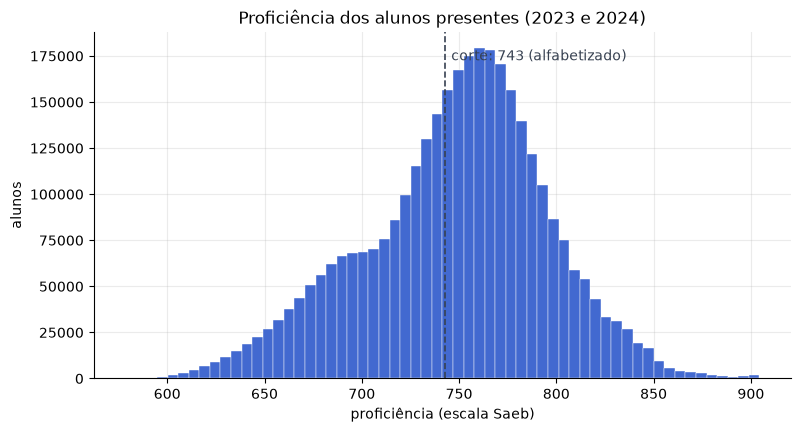

count    3354661.0
mean         748.4
std           47.6
min          578.5
25%          719.8
50%          753.2
75%          779.6
max          904.4
Name: proficiencia, dtype: float64

In [9]:
validos = alunos["proficiencia"].dropna()

fig, ax = plt.subplots()
ax.hist(validos, bins=60, color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(743, color=GRAFITE, linestyle="--", linewidth=1.2)
ax.text(746, ax.get_ylim()[1] * 0.95, "corte: 743 (alfabetizado)", color=GRAFITE, va="top")
ax.set_xlabel("proficiência (escala Saeb)")
ax.set_ylabel("alunos")
ax.set_title("Proficiência dos alunos presentes (2023 e 2024)")
plt.show()

validos.describe().round(1)

A distribuição é razoavelmente simétrica, com mediana em 753 — acima do corte. Mas o grosso da massa está perto da linha dos 743: pequenas mudanças no corte moveriam muito o indicador, o que ajuda a entender o cuidado do INEP em fixar esse valor por consenso técnico na Pesquisa Alfabetiza Brasil.

## A coluna `alfabetizado` bate com a regra dos 743?

A base já entrega o resultado pronto, mas quero recalcular por dois motivos: validar a consistência (é um check de qualidade de graça) e descobrir **qual denominador o indicador oficial usa** — todos os alunos ou só os presentes?

In [10]:
alunos["alfabetizado_num"] = pd.to_numeric(alunos["alfabetizado"], errors="coerce")
alunos["acima_do_corte"] = (alunos["proficiencia"] >= 743).astype(int)

comparacao = alunos.groupby("ano", observed=True).agg(
    oficial=("alfabetizado_num", "mean"),
    recalculo_sobre_todos=("acima_do_corte", "mean"),
)
comparacao["recalculo_so_presentes"] = (
    alunos[alunos["presenca"] == "1"].groupby("ano", observed=True)["acima_do_corte"].mean()
)
(comparacao * 100).round(1)

,oficial,recalculo_sobre_todos,recalculo_so_presentes
ano,,,
2023,50.2,50.2,58.4
2024,52.2,52.2,59.8


Dois achados bem objetivos:

- `oficial` e o recálculo sobre **todos** os alunos batem exatamente (50,2% / 52,2%): a coluna `alfabetizado` já embute a regra dos 743 pontos e trata o ausente como não alfabetizado. Bom sinal de consistência da fonte — e um check que vou automatizar na Silver;
- o recorte **só com presentes** dá números maiores (58,4% / 59,8%), na vizinhança da taxa publicada na tabela de metas (55,9% / 59,2%), mas não idêntico. A diferença deve vir do `peso_aluno` (peso amostral) e dos recortes de participação que o INEP aplica. Reproduzir a taxa oficial de ponta a ponta fica como tarefa da Gold — com a escolha de denominador e peso documentada.

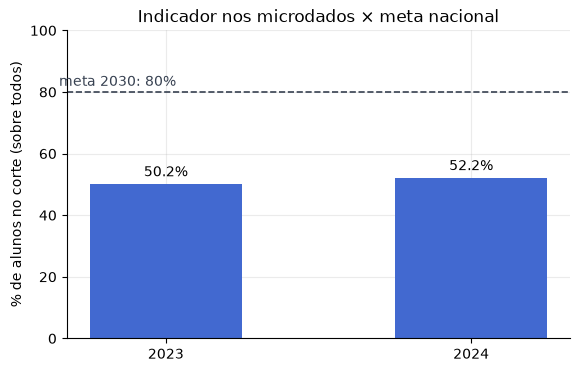

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4))
vals = (comparacao["oficial"] * 100).round(1)
bars = ax.bar(vals.index.astype(str), vals, color=AZUL, width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axhline(80, color=GRAFITE, linestyle="--", linewidth=1.2)
ax.text(-0.35, 82, "meta 2030: 80%", color=GRAFITE)
ax.set_ylim(0, 100)
ax.set_ylabel("% de alunos no corte (sobre todos)")
ax.set_title("Indicador nos microdados × meta nacional")
plt.show()

## As chaves fecham?

Para os joins da Silver, preciso saber se todo `id_municipio` dos microdados existe na tabela de municípios, e qual é a chave de unicidade de `alunos`.

In [12]:
ids_alunos = set(alunos["id_municipio"].unique())
ids_municipio = set(entidades["municipio"]["id_municipio"].unique())

print(f"municípios distintos nos microdados: {len(ids_alunos)}")
print(f"municípios na tabela municipio:      {len(ids_municipio)}")
print(f"sem correspondência: {sorted(ids_alunos - ids_municipio)}")
print(f"duplicatas de (id_aluno, ano): {alunos.duplicated(subset=['id_aluno', 'ano']).sum()}")

municípios distintos nos microdados: 5548
municípios na tabela municipio:      5550
sem correspondência: ['5219308']


duplicatas de (id_aluno, ano): 0


Quase perfeito: um único código (`5219308`) aparece nos microdados sem par na tabela de municípios — exatamente o caso que o check de integridade referencial da Silver vai mandar para a quarentena (pode ser município recém-criado ou código com grafia divergente; investigo lá). E a ausência de duplicatas confirma a chave natural de `alunos`: `(id_aluno, ano)`.

## O que levo para a Silver

Resumo do que esta exploração definiu de trabalho:

1. **Casting**: códigos (`rede`, `presenca`, `alfabetizado`, ids) para inteiro; `proficiencia` já vem como double;
2. **Decodificação**: rotular `rede` e `presenca` usando a tabela `dicionario` da fonte;
3. **Nulos de proficiência = ausência**: manter as linhas e sinalizar com flag — nunca imputar;
4. **Denominador do indicador**: a diferença entre "todos" e "só presentes" muda o número; para reproduzir a taxa oficial vou precisar testar o uso do `peso_aluno`. Decisão a documentar na Gold;
5. **Integridade referencial**: tratar o município órfão via quarentena e investigar o código;
6. **Chave de unicidade** de alunos: `(id_aluno, ano)` — validada, sem duplicatas;
7. **Metas**: empilhar Brasil / UF / município numa estrutura única (mesmo desenho de colunas nas três tabelas).